In [1]:
!git clone https://github.com/berenslab/MIDL24-segmentation_quality_control.git

Cloning into 'MIDL24-segmentation_quality_control'...
remote: Enumerating objects: 196, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 196 (delta 3), reused 11 (delta 0), pack-reused 178 (from 1)
Receiving objects: 100% (196/196), 369.99 MiB | 44.96 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Updating files: 100% (28/28), done.


In [2]:
%cd MIDL24-segmentation_quality_control

/kaggle/working/MIDL24-segmentation_quality_control


In [3]:
!pip install albumentations opencv-python tqdm scikit-image

In [4]:
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

class SegDataset(Dataset):
    def __init__(self, root, img_size=512):
        self.img_dir = os.path.join(root, "Original")
        self.mask_dir = os.path.join(root, "Ground truth")

        valid_ext = (".png", ".jpg", ".jpeg", ".tif", ".tiff")

        self.files = sorted([
            f for f in os.listdir(self.img_dir)
            if f.lower().endswith(valid_ext)
        ])

        self.img_tf = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor()
        ])

        self.mask_tf = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor()
        ])

        print("Images folder:", self.img_dir)
        print("Masks folder :", self.mask_dir)
        print("Total valid samples:", len(self.files))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.files[idx])
        mask_path = os.path.join(self.mask_dir, self.files[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        return self.img_tf(image), self.mask_tf(mask)


In [5]:
DATA_ROOT = "/kaggle/input/fundus-image-dataset-for-vessel-segmentation/train"

train_dataset = SegDataset(DATA_ROOT, img_size=512)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

Images folder: /kaggle/input/fundus-image-dataset-for-vessel-segmentation/train/Original
Masks folder : /kaggle/input/fundus-image-dataset-for-vessel-segmentation/train/Ground truth
Total valid samples: 600


In [6]:
imgs, masks = next(iter(train_loader))
print(imgs.shape, masks.shape)

torch.Size([4, 3, 512, 512]) torch.Size([4, 1, 512, 512])


In [7]:
import types
import sys

bunch = types.ModuleType("bunch")

class Bunch(dict):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.__dict__ = self

bunch.Bunch = Bunch
sys.modules["bunch"] = bunch

print("Bunch registered")

Bunch registered


In [8]:
import torch
from models.frunet import FR_UNet

device = "cuda" if torch.cuda.is_available() else "cpu"

model = FR_UNet(
    num_classes=1,
    num_channels=3
).to(device)

ckpt = torch.load(
    "trained/FRUNet_0.pth",
    map_location=device,
    weights_only=False
)

model.load_state_dict(ckpt["state_dict"])

print("FRUNet_0 pretrained weights loaded successfully")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

FRUNet_0 pretrained weights loaded successfully


In [9]:
!ls trained

FRUNet_0.pth  FRUNet_1.pth  FRUNet_2.pth  FRUNet_3.pth	FRUNet_4.pth


In [10]:
def dice_loss(pred, target, smooth=1e-5):
    pred = torch.sigmoid(pred)
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(1)
    dice = (2. * intersection + smooth) / (
        pred.sum(1) + target.sum(1) + smooth
    )
    return 1 - dice.mean()

criterion_bce = torch.nn.BCEWithLogitsLoss()

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

criterion_bce = torch.nn.BCEWithLogitsLoss()

def dice_loss(pred, target, smooth=1e-5):
    pred = torch.sigmoid(pred)
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)
    intersection = (pred * target).sum(1)
    dice = (2. * intersection + smooth) / (
        pred.sum(1) + target.sum(1) + smooth
    )
    return 1 - dice.mean()

In [12]:
from models.frunet import FR_UNet
import torch

def finetune_one_model(pretrained_path, save_path, epochs=10, lr=1e-4):
    # create model
    model = FR_UNet(num_classes=1, num_channels=3).to(device)

    # load pretrained checkpoint
    ckpt = torch.load(
        pretrained_path,
        map_location=device,
        weights_only=False
    )
    model.load_state_dict(ckpt["state_dict"])

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    print(f"\n🚀 Fine-tuning {pretrained_path}")

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for imgs, masks in train_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            preds = model(imgs)

            loss = criterion_bce(preds, masks) + dice_loss(preds, masks)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(train_loader):.4f}")

    torch.save(model.state_dict(), save_path)
    print(f"✅ Saved fine-tuned weights to {save_path}")

In [13]:
for i in range(5):
    finetune_one_model(
        pretrained_path=f"trained/FRUNet_{i}.pth",
        save_path=f"FRUNet_{i}_finetuned.pth",
        epochs=10,
        lr=1e-4
    )


🚀 Fine-tuning trained/FRUNet_0.pth
Epoch [1/10] Loss: 0.2256
Epoch [2/10] Loss: 0.2172
Epoch [3/10] Loss: 0.2120
Epoch [4/10] Loss: 0.2108
Epoch [5/10] Loss: 0.2086
Epoch [6/10] Loss: 0.2070
Epoch [7/10] Loss: 0.2038
Epoch [8/10] Loss: 0.2028
Epoch [9/10] Loss: 0.2017
Epoch [10/10] Loss: 0.1999
✅ Saved fine-tuned weights to FRUNet_0_finetuned.pth

🚀 Fine-tuning trained/FRUNet_1.pth
Epoch [1/10] Loss: 0.2266
Epoch [2/10] Loss: 0.2163
Epoch [3/10] Loss: 0.2123
Epoch [4/10] Loss: 0.2124
Epoch [5/10] Loss: 0.2092
Epoch [6/10] Loss: 0.2065
Epoch [7/10] Loss: 0.2050
Epoch [8/10] Loss: 0.2031
Epoch [9/10] Loss: 0.2014
Epoch [10/10] Loss: 0.1995
✅ Saved fine-tuned weights to FRUNet_1_finetuned.pth

🚀 Fine-tuning trained/FRUNet_2.pth
Epoch [1/10] Loss: 0.2250
Epoch [2/10] Loss: 0.2158
Epoch [3/10] Loss: 0.2127
Epoch [4/10] Loss: 0.2102
Epoch [5/10] Loss: 0.2085
Epoch [6/10] Loss: 0.2059
Epoch [7/10] Loss: 0.2040
Epoch [8/10] Loss: 0.2014
Epoch [9/10] Loss: 0.2007
Epoch [10/10] Loss: 0.1995
✅ S

In [14]:
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

class SegDataset(Dataset):
    def __init__(self, root, img_size=512):
        self.img_dir = os.path.join(root, "Original")
        self.mask_dir = os.path.join(root, "Ground truth")

        valid_ext = (".png", ".jpg", ".jpeg", ".tif", ".tiff")
        self.files = sorted([
            f for f in os.listdir(self.img_dir)
            if f.lower().endswith(valid_ext)
        ])

        self.img_tf = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor()
        ])

        self.mask_tf = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor()
        ])

        print("✅ Test samples:", len(self.files))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.files[idx])).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, self.files[idx])).convert("L")
        return self.img_tf(img), self.mask_tf(mask)

In [15]:
TEST_ROOT = "/kaggle/input/fundus-image-dataset-for-vessel-segmentation/test"

test_dataset = SegDataset(TEST_ROOT, img_size=512)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

✅ Test samples: 200


In [16]:
import torch
from models.frunet import FR_UNet

device = "cuda" if torch.cuda.is_available() else "cpu"

models = []

for i in range(5):
    model = FR_UNet(num_classes=1, num_channels=3).to(device)
    model.load_state_dict(
        torch.load(f"FRUNet_{i}_finetuned.pth", map_location=device)
    )
    model.eval()
    models.append(model)

print("✅ All 5 fine-tuned models loaded")

✅ All 5 fine-tuned models loaded


In [17]:
def dice_score(pred, target, smooth=1e-5):
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    return (2. * intersection + smooth) / (union + smooth)

In [18]:
import torch.nn.functional as F

total_dice = 0
count = 0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = []

        for model in models:
            out = model(imgs)
            preds.append(torch.sigmoid(out))

        # 🔥 ensemble average
        ensemble_pred = torch.mean(torch.stack(preds), dim=0)

        batch_dice = dice_score(ensemble_pred, masks)
        total_dice += batch_dice.item()
        count += 1

final_dice = total_dice / count
print(f"\n🎯 ENSEMBLE TEST DICE SCORE: {final_dice:.4f}")


🎯 ENSEMBLE TEST DICE SCORE: 0.9085


In [19]:
import torch
from models.frunet import FR_UNet

device = "cuda" if torch.cuda.is_available() else "cpu"

models = []
for i in range(5):
    m = FR_UNet(num_classes=1, num_channels=3).to(device)
    m.load_state_dict(torch.load(f"FRUNet_{i}_finetuned.pth", map_location=device))
    m.eval()
    models.append(m)

print("✅ Ensemble models ready")

✅ Ensemble models ready


In [20]:
import numpy as np

imgs, masks = next(iter(test_loader))
imgs = imgs.to(device)
masks = masks.to(device)

In [21]:
with torch.no_grad():
    preds = []
    for model in models:
        preds.append(torch.sigmoid(model(imgs)))

    ensemble_pred = torch.mean(torch.stack(preds), dim=0)

binary_pred = (ensemble_pred > 0.5).float()

In [22]:
import matplotlib.pyplot as plt

def visualize_sample(image, gt, pred):
    image = image.permute(1, 2, 0).cpu().numpy()
    gt = gt.squeeze().cpu().numpy()
    pred = pred.squeeze().cpu().numpy()

    fig, axs = plt.subplots(1, 4, figsize=(18, 5))

    axs[0].imshow(image)
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    axs[1].imshow(gt, cmap="gray")
    axs[1].set_title("Ground Truth")
    axs[1].axis("off")

    axs[2].imshow(pred, cmap="gray")
    axs[2].set_title("Ensemble Prediction")
    axs[2].axis("off")

    axs[3].imshow(image)
    axs[3].imshow(pred, cmap="Reds", alpha=0.5)
    axs[3].set_title("Overlay (Prediction)")
    axs[3].axis("off")

    plt.tight_layout()
    plt.show()

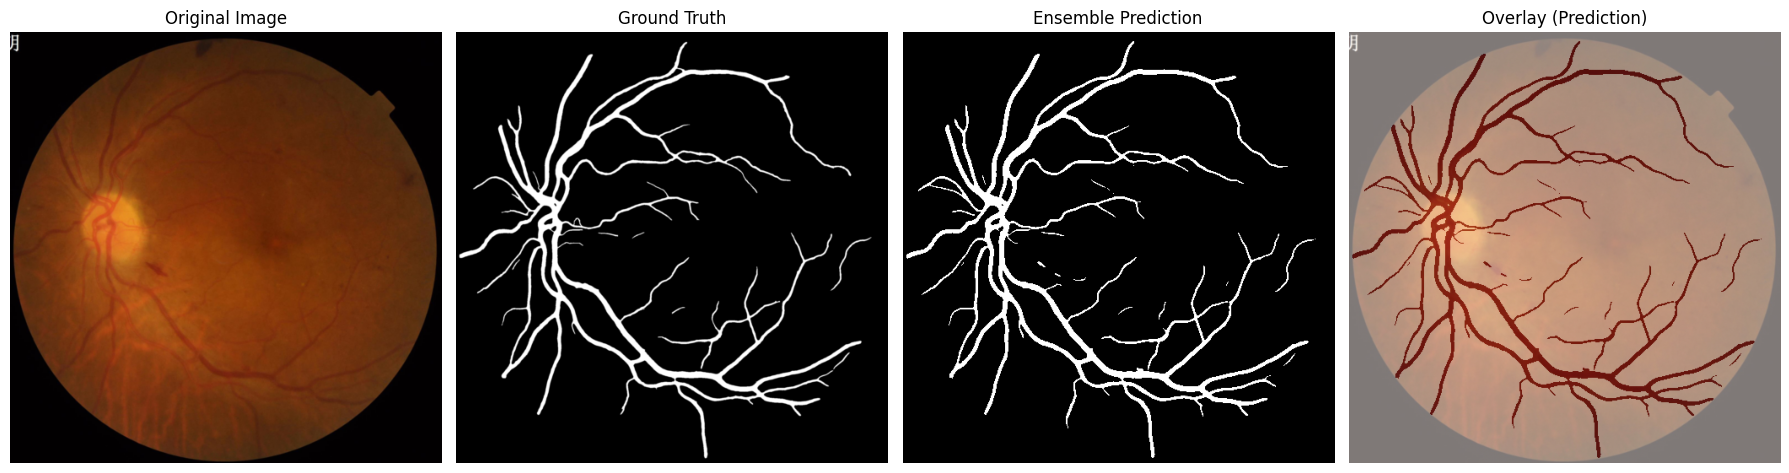

In [23]:
visualize_sample(
    imgs[0],
    masks[0],
    binary_pred[0]
)

In [24]:
single_model = FR_UNet(num_classes=1, num_channels=3).to(device)
single_model.load_state_dict(
    torch.load("FRUNet_0_finetuned.pth", map_location=device)
)
single_model.eval()

print("✅ Single model (FRUNet_0) loaded")

✅ Single model (FRUNet_0) loaded


In [25]:
imgs, masks = next(iter(test_loader))
imgs = imgs.to(device)
masks = masks.to(device)

In [26]:
with torch.no_grad():
    # single model prediction
    single_pred = torch.sigmoid(single_model(imgs))
    single_bin = (single_pred > 0.5).float()

    # ensemble prediction
    preds = []
    for model in models:
        preds.append(torch.sigmoid(model(imgs)))
    ensemble_pred = torch.mean(torch.stack(preds), dim=0)
    ensemble_bin = (ensemble_pred > 0.5).float()

In [27]:
import matplotlib.pyplot as plt

def visualize_single_vs_ensemble(image, gt, single_pred, ensemble_pred):
    image = image.permute(1, 2, 0).cpu().numpy()
    gt = gt.squeeze().cpu().numpy()
    single_pred = single_pred.squeeze().cpu().numpy()
    ensemble_pred = ensemble_pred.squeeze().cpu().numpy()

    fig, axs = plt.subplots(1, 5, figsize=(22, 5))

    axs[0].imshow(image)
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    axs[1].imshow(gt, cmap="gray")
    axs[1].set_title("Ground Truth")
    axs[1].axis("off")

    axs[2].imshow(single_pred, cmap="gray")
    axs[2].set_title("Single Model (FRUNet_0)")
    axs[2].axis("off")

    axs[3].imshow(ensemble_pred, cmap="gray")
    axs[3].set_title("Ensemble Prediction")
    axs[3].axis("off")

    axs[4].imshow(image)
    axs[4].imshow(ensemble_pred, cmap="Reds", alpha=0.5)
    axs[4].set_title("Overlay (Ensemble)")
    axs[4].axis("off")

    plt.tight_layout()
    plt.show()

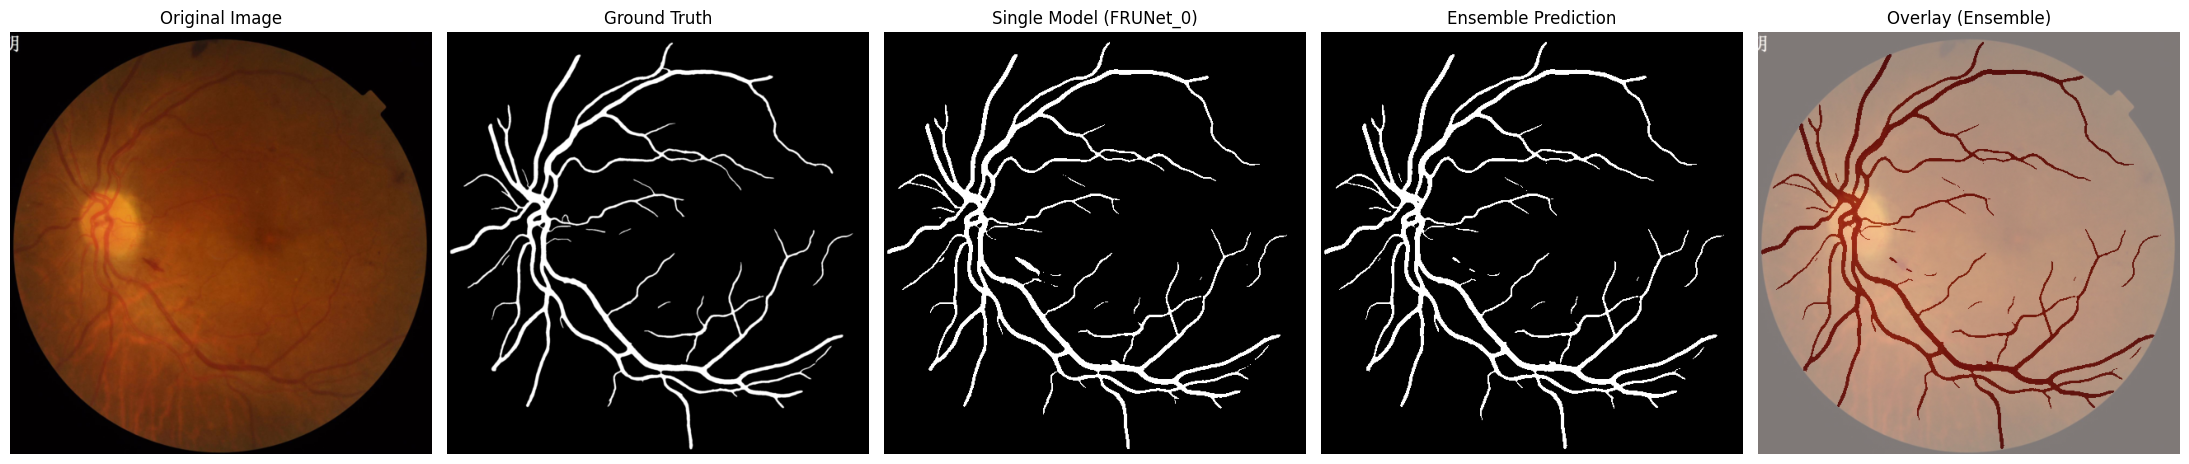

In [28]:
visualize_single_vs_ensemble(
    imgs[0],
    masks[0],
    single_bin[0],
    ensemble_bin[0]
)

In [41]:
import torch
from models.frunet import FR_UNet

In [48]:
model_paths = [
    "trained/FRUNet_0_finetuned.pth",
    "trained/FRUNet_1_finetuned.pth",
    "trained/FRUNet_2_finetuned.pth",
    "trained/FRUNet_3_finetuned.pth",
    "trained/FRUNet_4_finetuned.pth",
]

models = []

for path in model_paths:
    model = FR_UNet(
        num_classes=1,
        num_channels=3,
        feature_scale=2,
        dropout=0.1
    ).to(device)

    ckpt = torch.load(path, map_location=device)

    # supports both pure state_dict and full checkpoint
    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        model.load_state_dict(ckpt["state_dict"])
    else:
        model.load_state_dict(ckpt)

    model.eval()
    models.append(model)

print(f"✅ Loaded {len(models)} finetuned models")

✅ Loaded 5 finetuned models


In [44]:
import os

print("📂 Current directory:", os.getcwd())
print("\nFiles here:")
print(os.listdir("."))

📂 Current directory: /kaggle/working/MIDL24-segmentation_quality_control

Files here:
['FRUNet_1_finetuned.pth', 'fig', 'data', '.gitignore', '3_figure_2.ipynb', '3_figure_4.ipynb', 'config_all_imgs.yaml', 'models', '0_pass_forward.ipynb', 'FRUNet_0_finetuned.pth', '.git', 'utils', 'config_all_patches.yaml', 'README.md', 'trained', '2_estimate_DSC.ipynb', '3_figure_5.ipynb', '3_figure_3.ipynb', 'FRUNet_2_finetuned.pth', 'FRUNet_4_finetuned.pth', 'config.yaml', 'paths.yaml', '1_calibrate.ipynb', 'FRUNet_3_finetuned.pth']


In [45]:
import shutil
import os

for i in range(5):
    src = f"FRUNet_{i}_finetuned.pth"
    dst = f"trained/FRUNet_{i}_finetuned.pth"
    if os.path.exists(src):
        shutil.move(src, dst)
        print(f"✅ Moved {src} → {dst}")

✅ Moved FRUNet_0_finetuned.pth → trained/FRUNet_0_finetuned.pth
✅ Moved FRUNet_1_finetuned.pth → trained/FRUNet_1_finetuned.pth
✅ Moved FRUNet_2_finetuned.pth → trained/FRUNet_2_finetuned.pth
✅ Moved FRUNet_3_finetuned.pth → trained/FRUNet_3_finetuned.pth
✅ Moved FRUNet_4_finetuned.pth → trained/FRUNet_4_finetuned.pth


In [49]:
def compute_uncertainty_features(models, imgs):
    preds = []

    for model in models:
        with torch.no_grad():
            p = torch.sigmoid(model(imgs))
            preds.append(p)

    preds = torch.stack(preds)          # [E, B, 1, H, W]
    mean_pred = preds.mean(dim=0)
    var_pred = preds.var(dim=0)

    entropy = -(
        mean_pred * torch.log(mean_pred + 1e-8) +
        (1 - mean_pred) * torch.log(1 - mean_pred + 1e-8)
    )

    fg_ratio = mean_pred.mean(dim=[1,2,3])  # per image

    features = torch.stack([
        var_pred.mean(dim=[1,2,3]),
        entropy.mean(dim=[1,2,3]),
        fg_ratio
    ], dim=1)

    return features.cpu().numpy()

In [50]:
def dice_score(pred, target, eps=1e-8):
    pred = (pred > 0.5).float()
    inter = (pred * target).sum()
    union = pred.sum() + target.sum()
    return (2 * inter + eps) / (union + eps)

In [52]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

class FundusDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_size=512):
        self.img_dir = img_dir
        self.mask_dir = mask_dir

        self.files = [
            f for f in os.listdir(img_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif"))
        ]

        self.img_tf = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor()
        ])

        self.mask_tf = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.files[idx])
        mask_path = os.path.join(self.mask_dir, self.files[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = self.img_tf(image)
        mask = self.mask_tf(mask)

        return image, mask

In [53]:
DATA_ROOT = "/kaggle/input/fundus-image-dataset-for-vessel-segmentation"

TRAIN_IMG = f"{DATA_ROOT}/train/Original"
TRAIN_MASK = f"{DATA_ROOT}/train/Ground truth"

TEST_IMG = f"{DATA_ROOT}/test/Original"
TEST_MASK = f"{DATA_ROOT}/test/Ground truth"

In [54]:
from sklearn.model_selection import train_test_split

full_dataset = FundusDataset(TRAIN_IMG, TRAIN_MASK)

train_idx, calib_idx = train_test_split(
    range(len(full_dataset)),
    test_size=0.2,
    random_state=42
)

train_set = torch.utils.data.Subset(full_dataset, train_idx)
calib_set = torch.utils.data.Subset(full_dataset, calib_idx)

test_set = FundusDataset(TEST_IMG, TEST_MASK)

In [55]:
train_loader = DataLoader(
    train_set,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

calib_loader = DataLoader(
    calib_set,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_set,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [56]:
X, y = [], []

for imgs, masks in calib_loader:   # loader WITH GT
    imgs = imgs.to(device)
    masks = masks.to(device)

    features = compute_uncertainty_features(models, imgs)

    with torch.no_grad():
        mean_pred = torch.mean(
            torch.stack([torch.sigmoid(m(imgs)) for m in models]),
            dim=0
        )

    for i in range(imgs.size(0)):
        d = dice_score(mean_pred[i], masks[i]).item()
        X.append(features[i])
        y.append(d)

X = np.array(X)
y = np.array(y)

print("Calibration data:", X.shape, y.shape)

Calibration data: (120, 3) (120,)


In [58]:
from sklearn.ensemble import RandomForestRegressor

calib_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

calib_model.fit(X, y)

print("✅ Calibration model trained")

✅ Calibration model trained


In [59]:
import pickle

with open("trained/calibration_model.pkl", "wb") as f:
    pickle.dump(calib_model, f)

print("💾 Calibration model saved")

💾 Calibration model saved


In [60]:
import pickle

with open("trained/calibration_model.pkl", "rb") as f:
    calib_model = pickle.load(f)

print("✅ Calibration model loaded")

✅ Calibration model loaded


In [61]:
est_dices = []

for imgs, _ in test_loader:   # masks NOT used
    imgs = imgs.to(device)

    # extract uncertainty features
    features = compute_uncertainty_features(models, imgs)

    # predict Dice without GT
    est = calib_model.predict(features)

    est_dices.extend(est)

est_dices = np.array(est_dices)

print(f"📐 ESTIMATED DICE (mean): {est_dices.mean():.4f}")
print(f"📊 ESTIMATED DICE (std):  {est_dices.std():.4f}")

📐 ESTIMATED DICE (mean): 0.8650
📊 ESTIMATED DICE (std):  0.0315


In [62]:
true_dices = []

for imgs, masks in test_loader:
    imgs = imgs.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        mean_pred = torch.mean(
            torch.stack([torch.sigmoid(m(imgs)) for m in models]),
            dim=0
        )

    for i in range(imgs.size(0)):
        d = dice_score(mean_pred[i], masks[i]).item()
        true_dices.append(d)

print("True Dice mean:", np.mean(true_dices))
print("Estimated Dice mean:", np.mean(est_dices))

True Dice mean: 0.8489366887509823
Estimated Dice mean: 0.8649949339747428
